# Load Libraries

In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import train/test split for stratified fraud detection holdout
from sklearn.model_selection import train_test_split

# Import StandardScaler to put V-features and Amount on comparable scale
from sklearn.preprocessing import StandardScaler

# Import dimensionality reduction algorithms from Chapter 4
from sklearn.decomposition import PCA, FastICA, MiniBatchDictionaryLearning

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Import metrics for imbalanced anomaly ranking evaluation (labels used for assessment only)
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
)

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
#C:\Users\tiwal\Desktop\OSAP\CIMT\UNSUPERVISED LEARNING\compressed_creditcard.csv

data = pd.read_csv("/content/drive/MyDrive/Credit Card/creditcard.csv")

print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

### Data Exploration

In [4]:
data.shape

(284807, 31)

In [5]:
data.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### Statistical Summary

In [7]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Observation
- PCA-transformed features V1–V28 are approximately centered around zero.
- Amount is highly skewed.
- Time ranges from 0 to 172792 seconds.

In [8]:
data.duplicated().sum()

np.int64(1081)

### Missing Values Analysis

In [9]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## Observation
- No missing values.
- Dataset is complete.

# Data Processing

### Outlier Detection

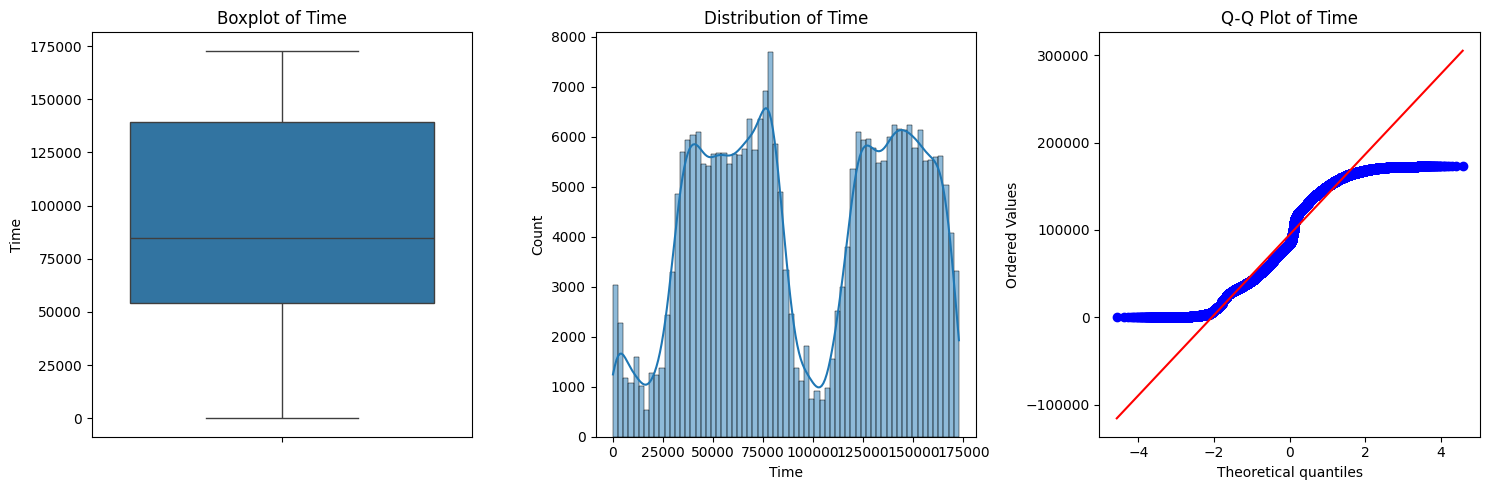

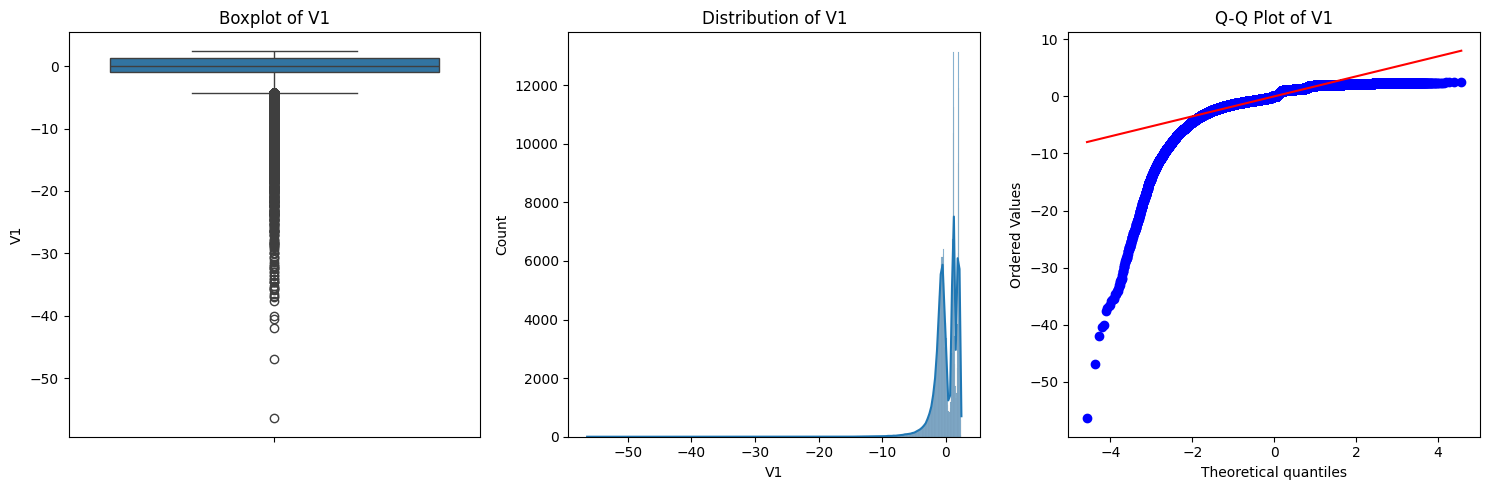

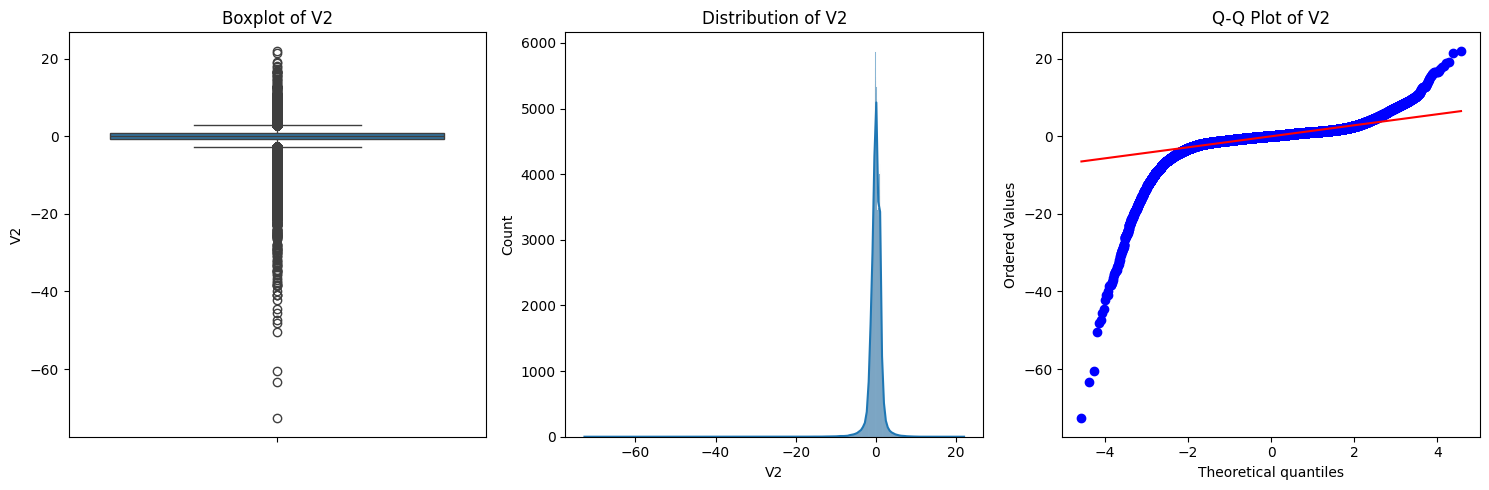

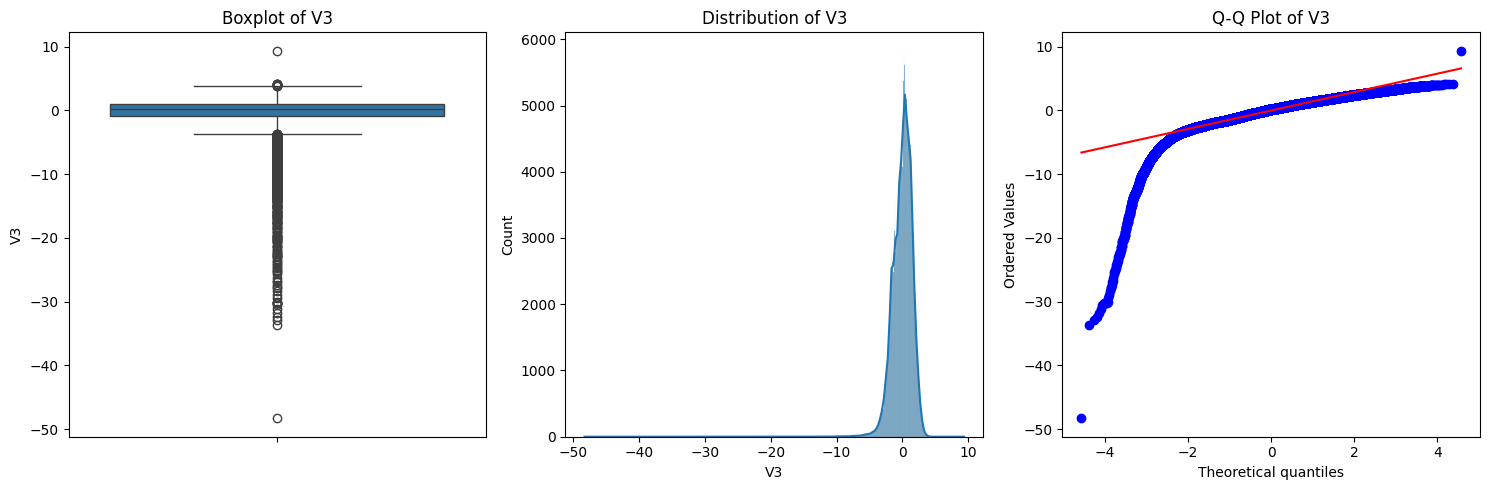

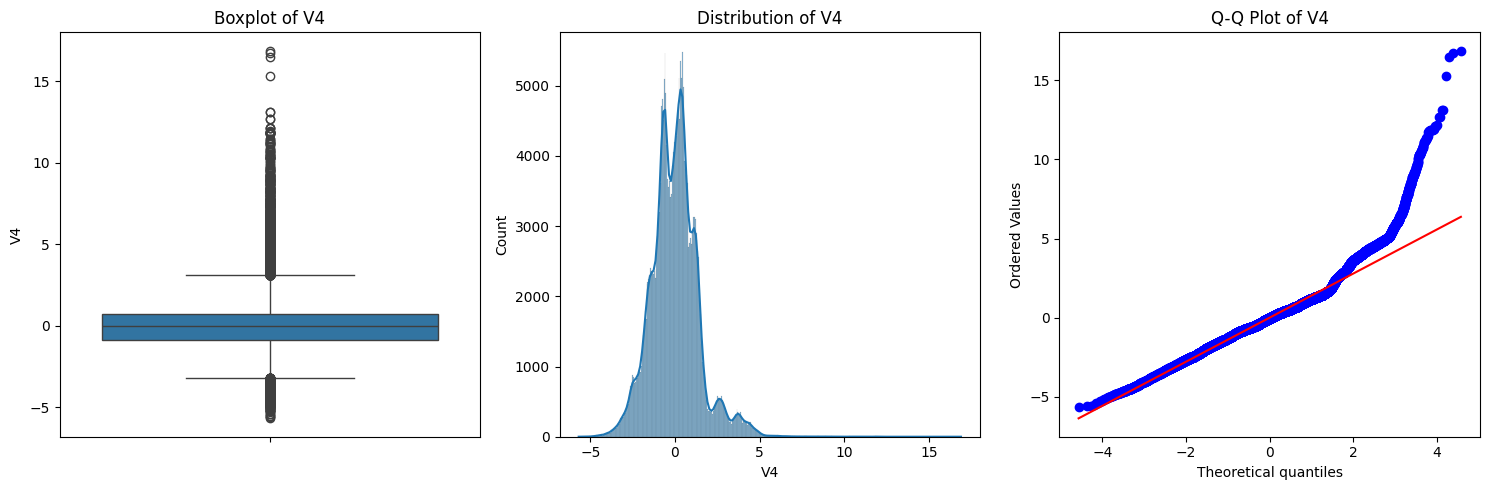

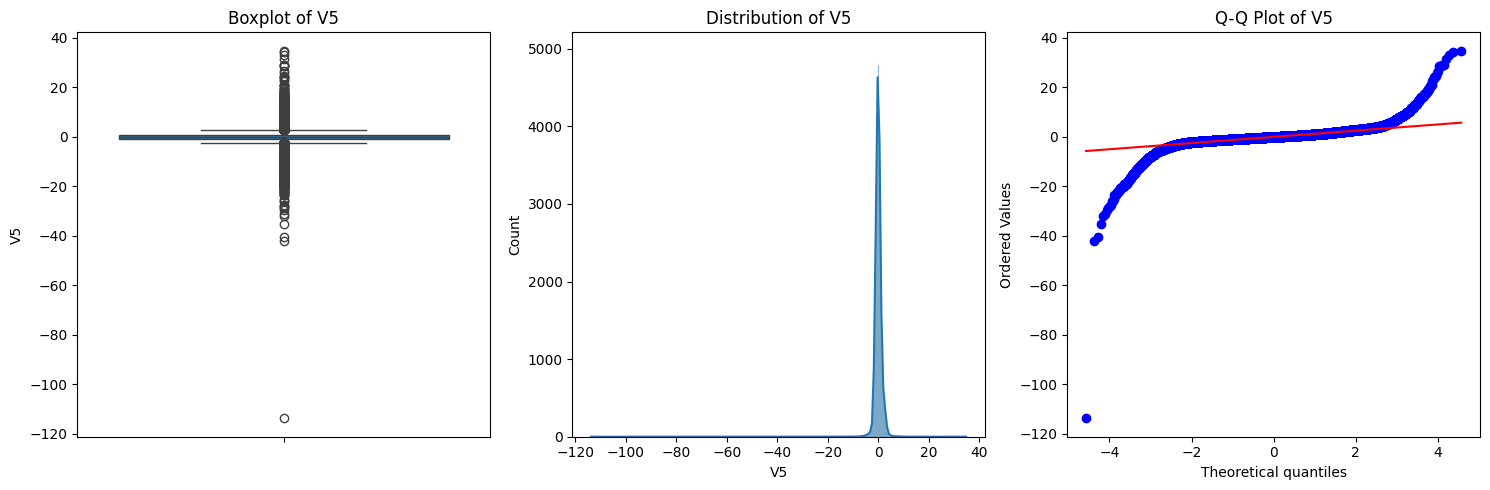

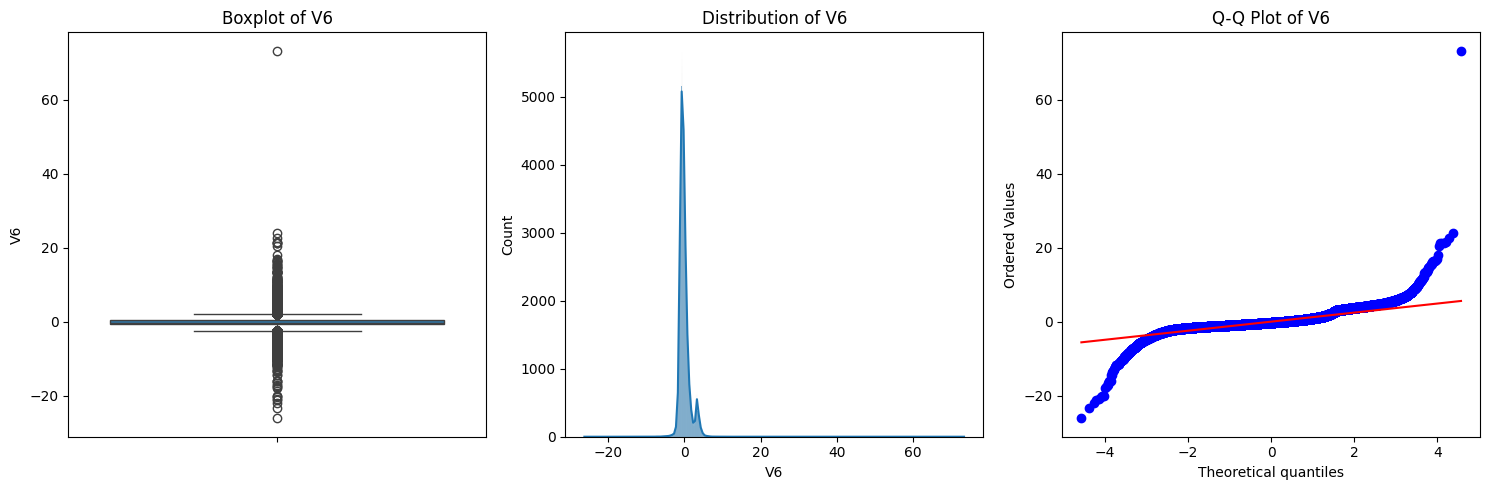

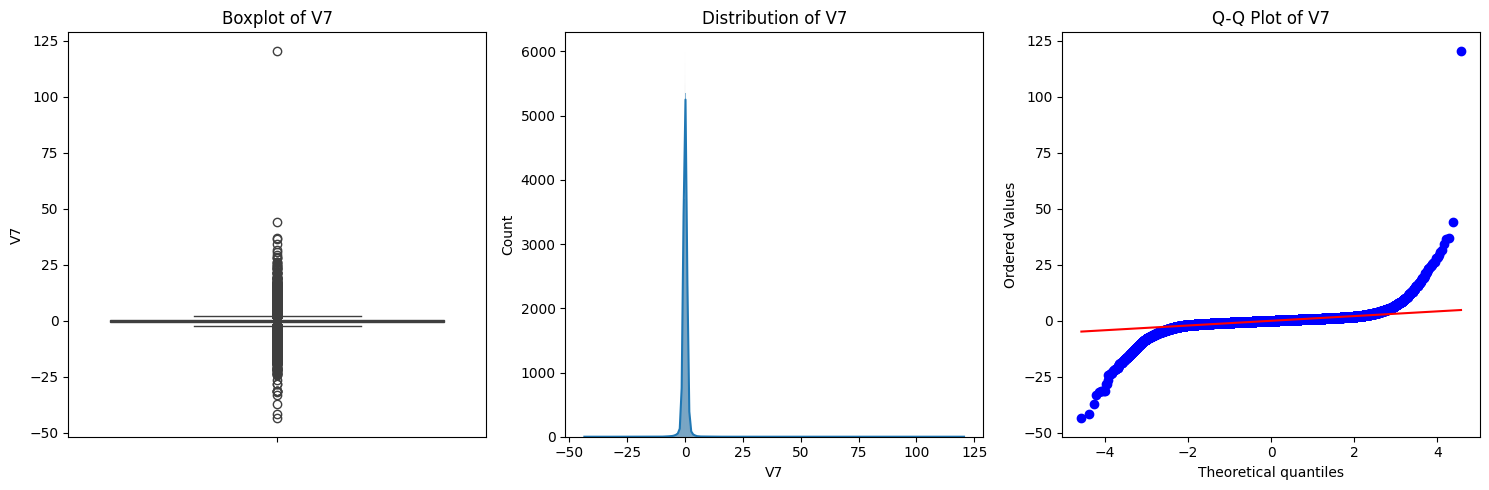

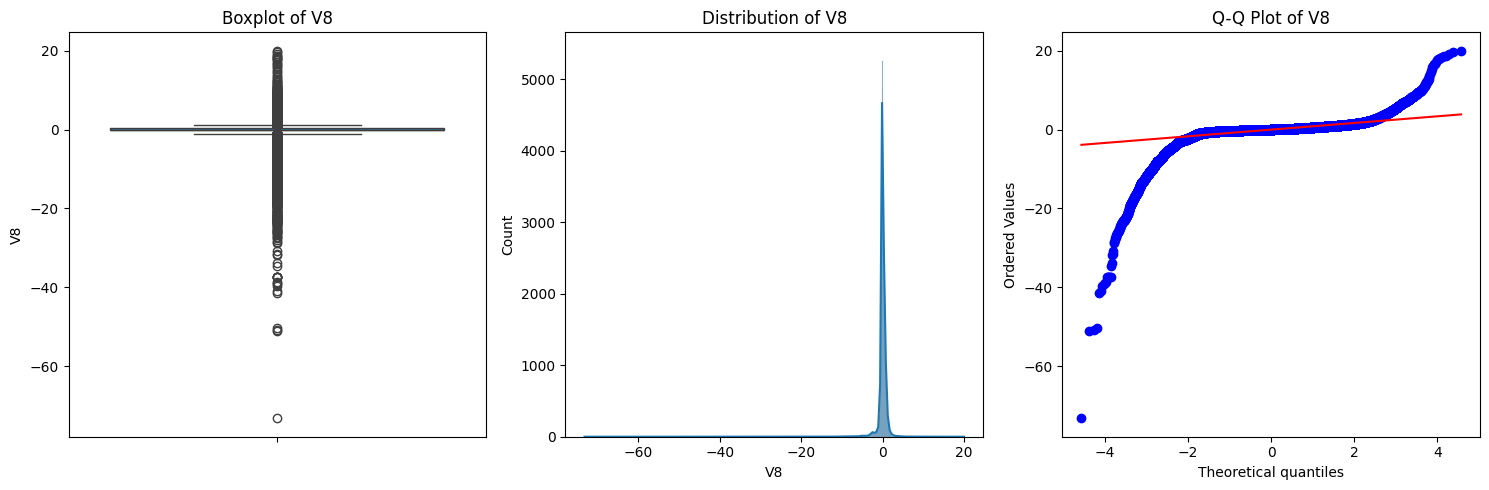

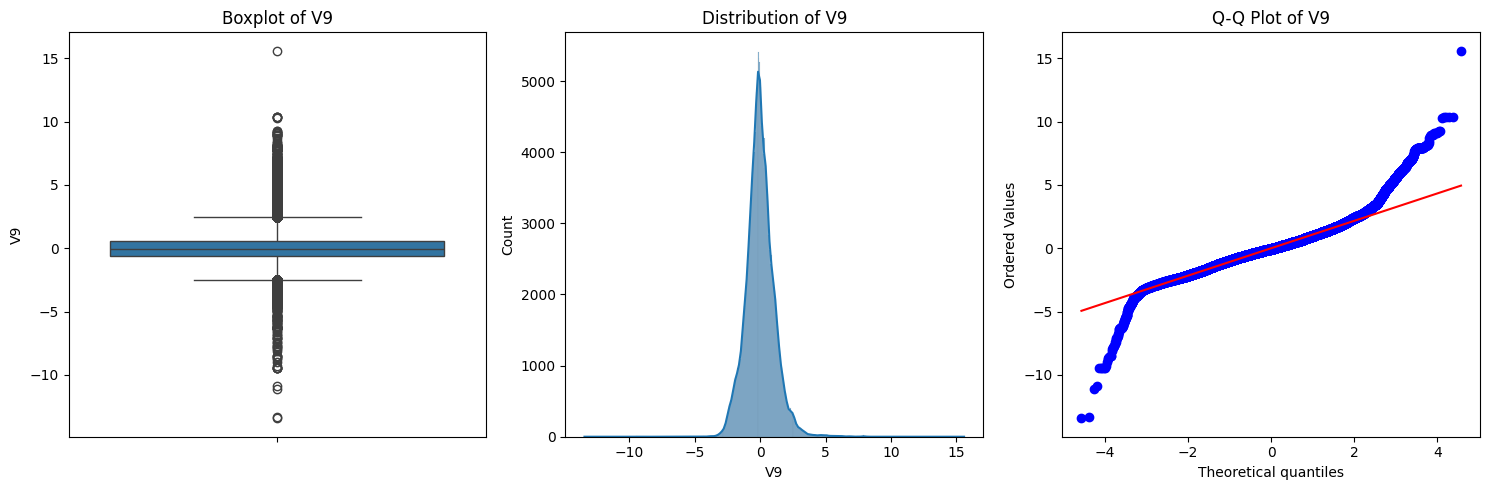

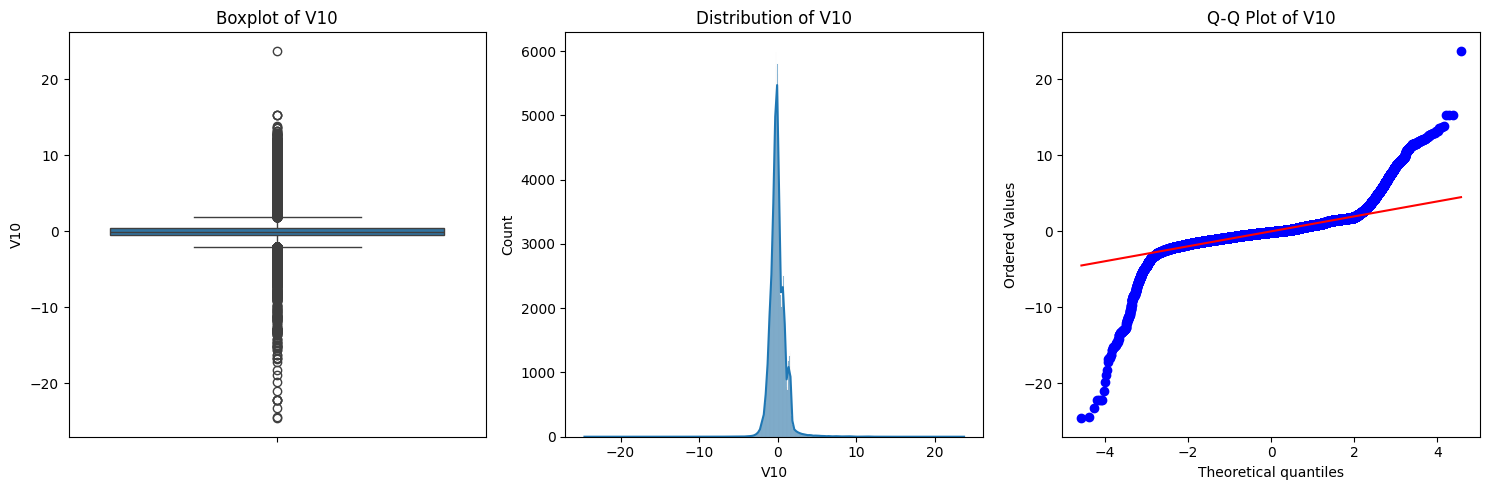

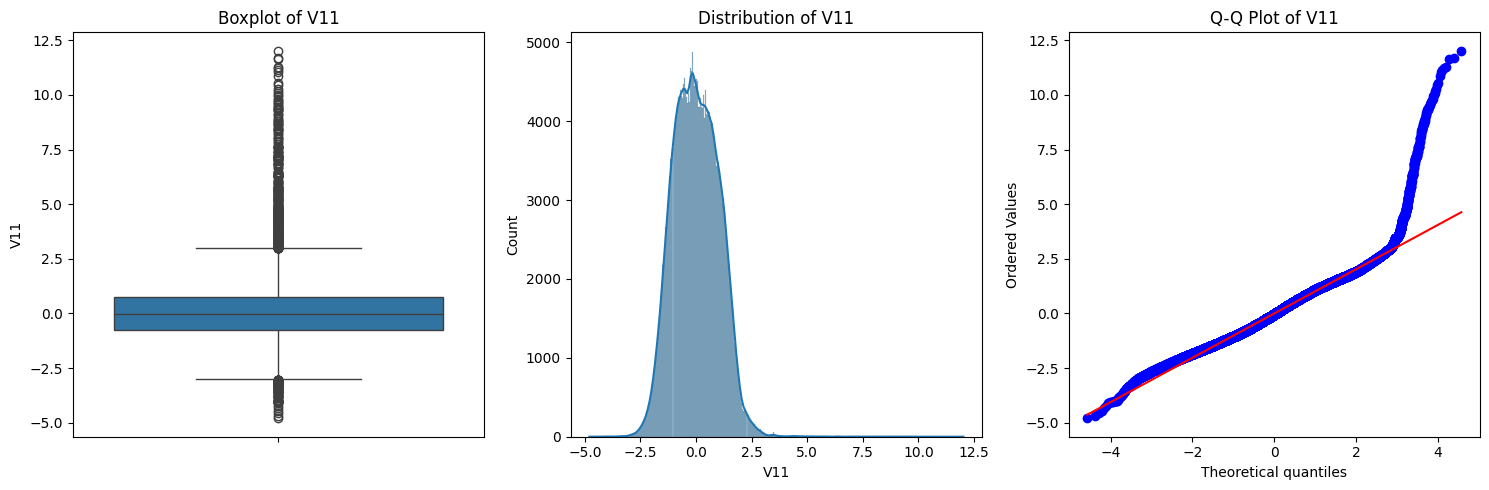

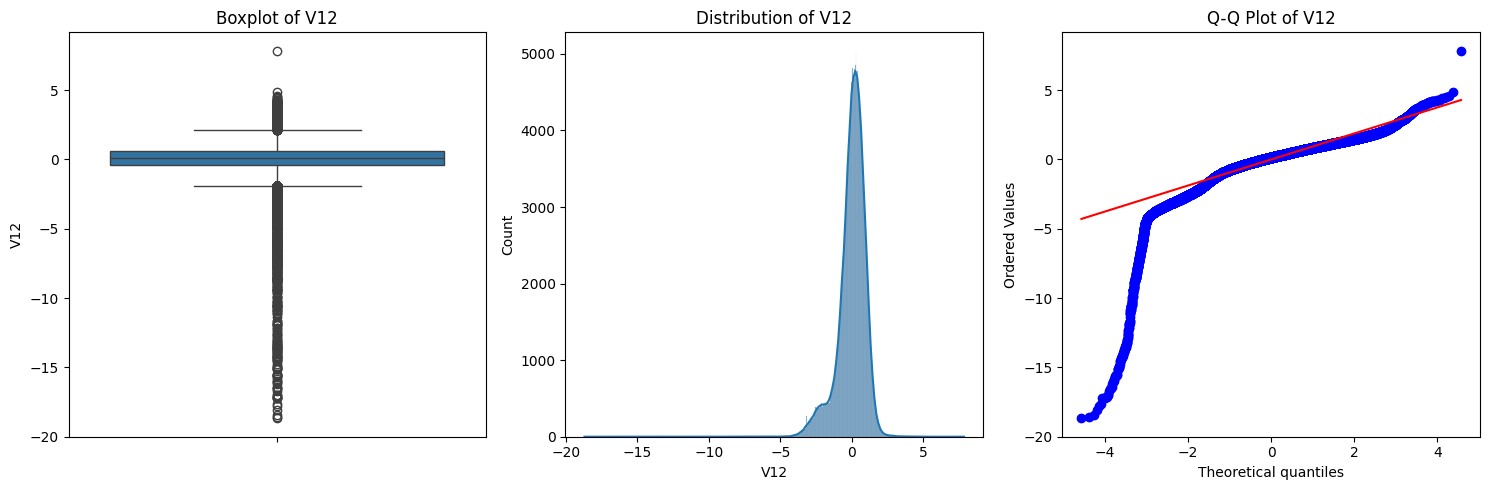

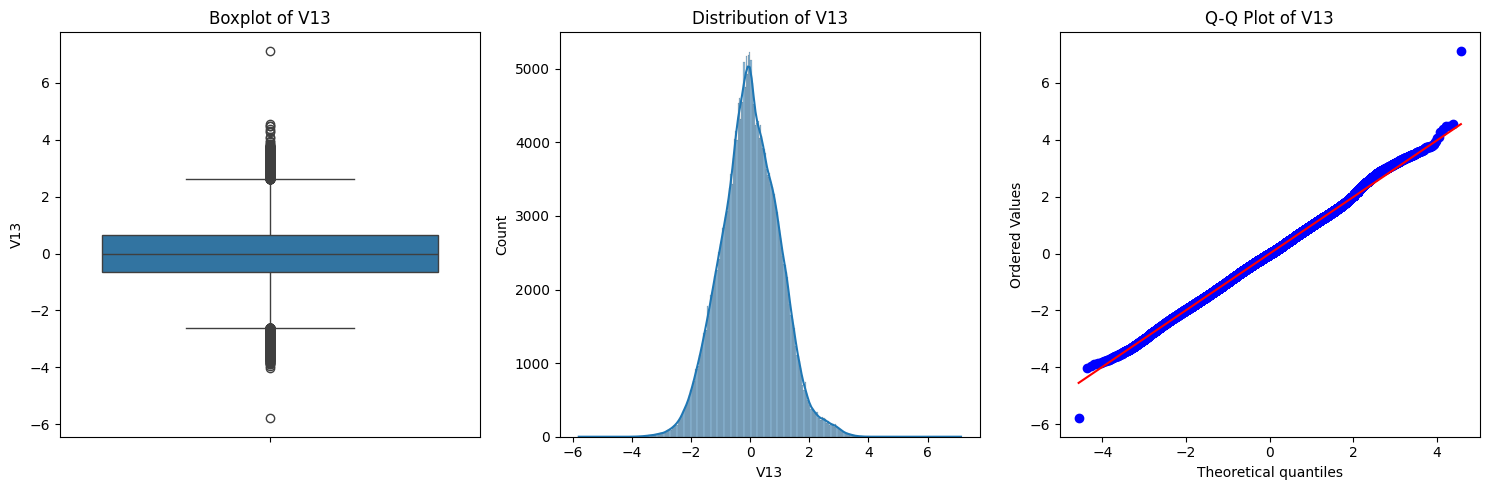

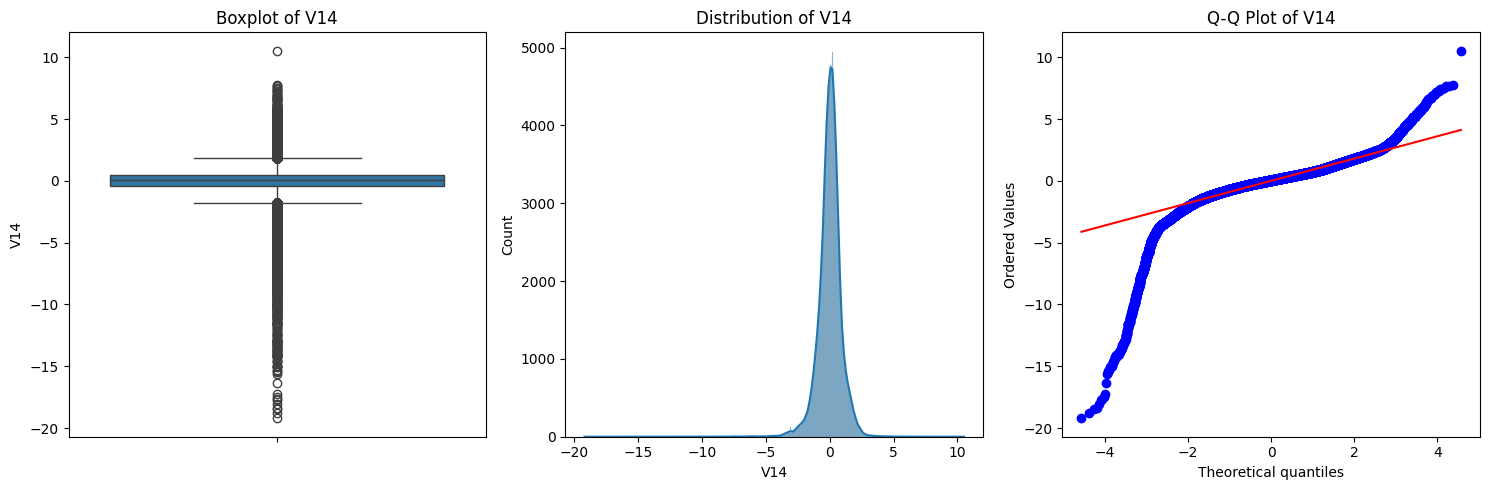

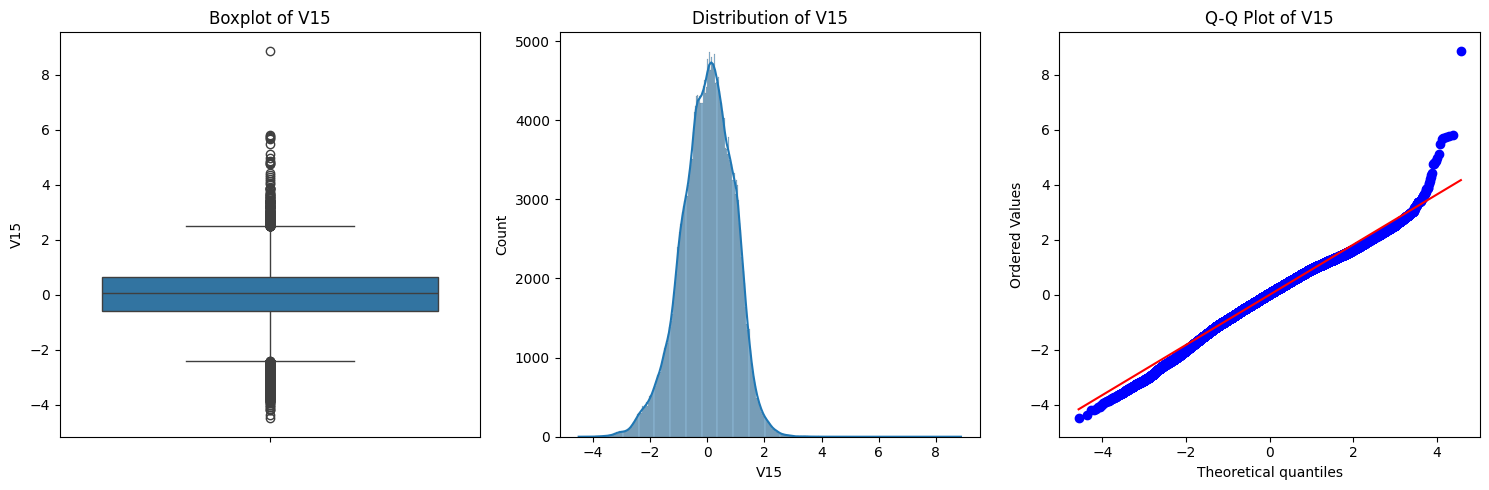

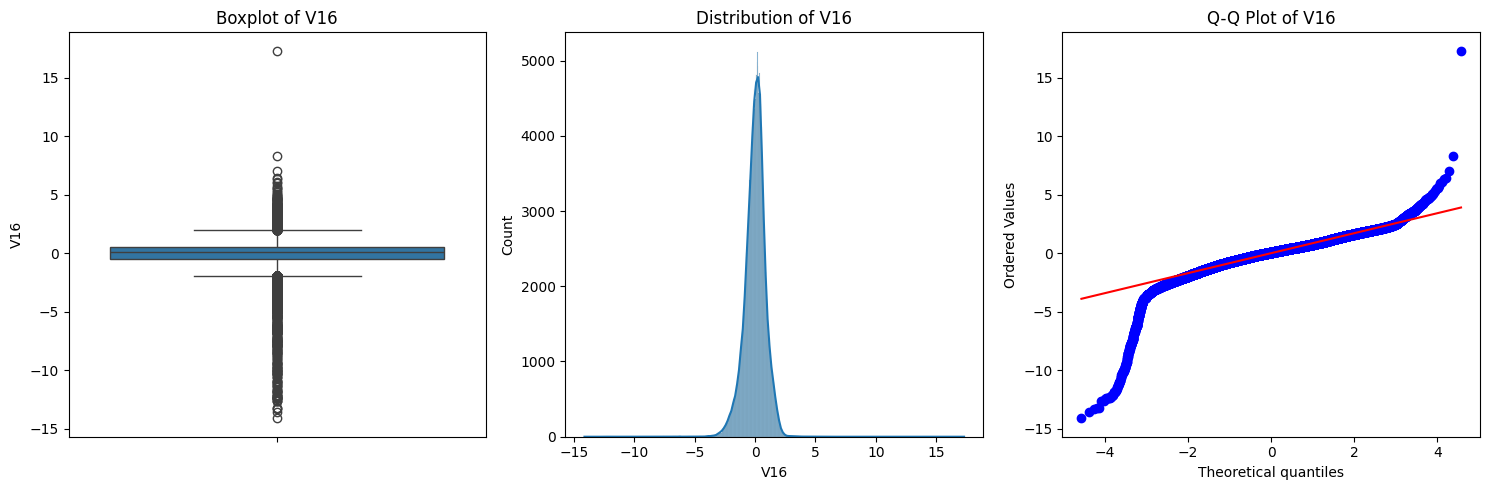

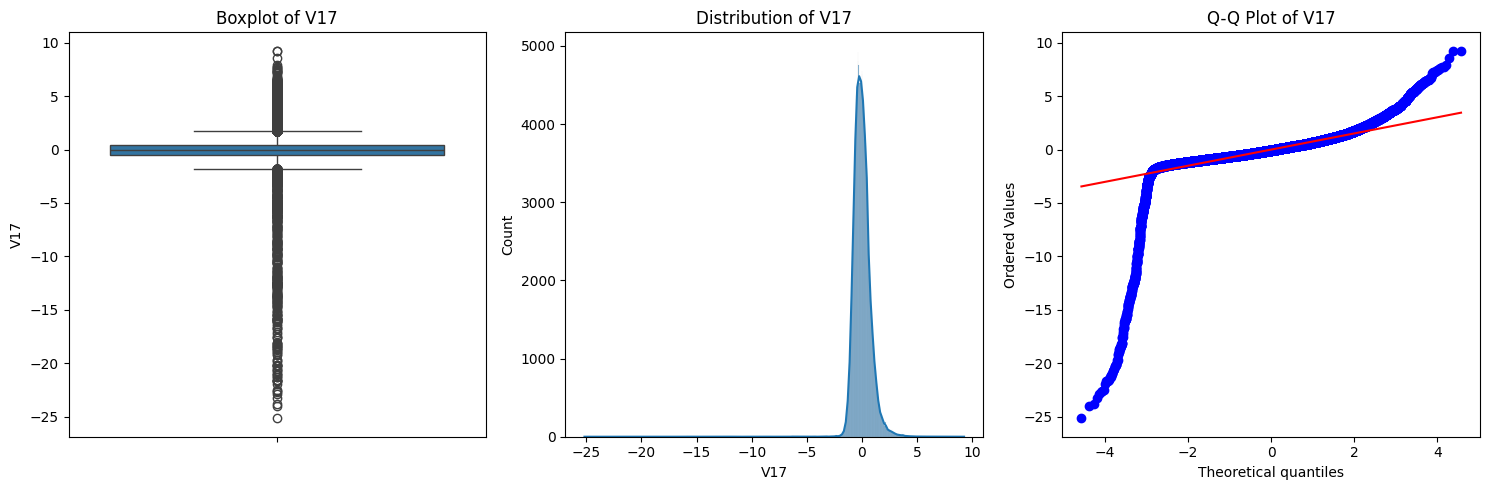

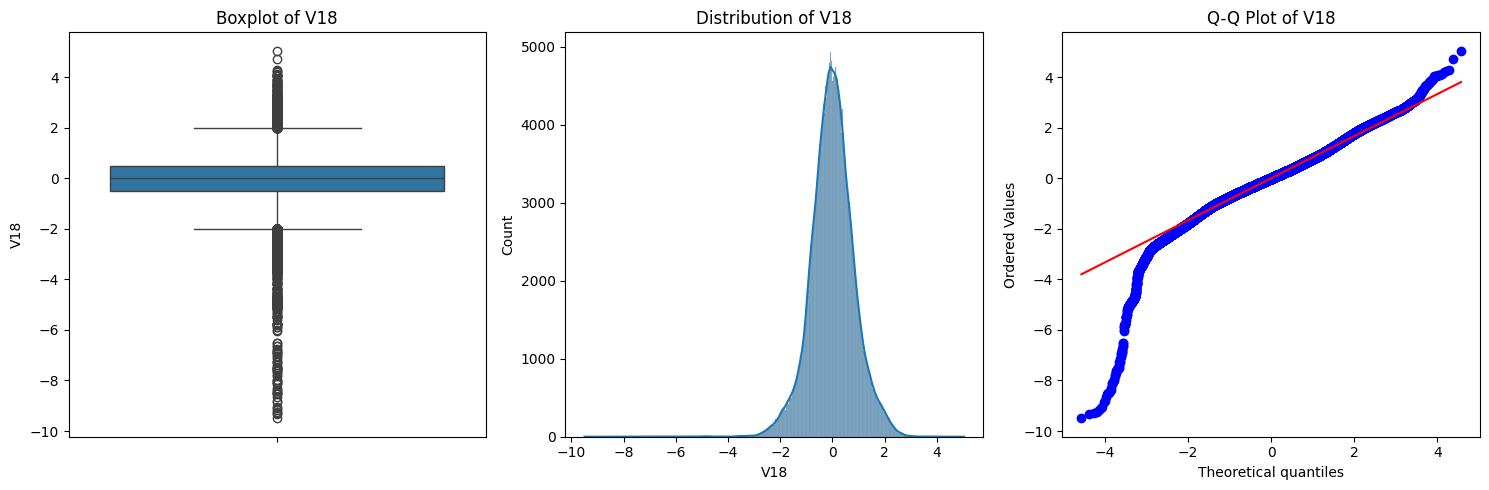

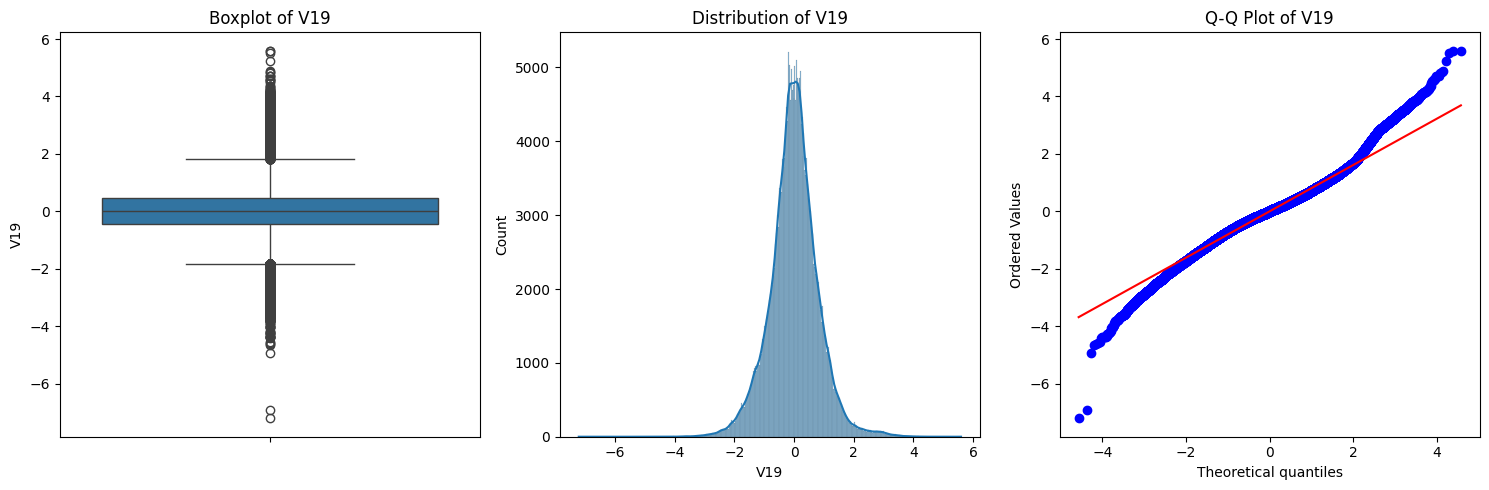

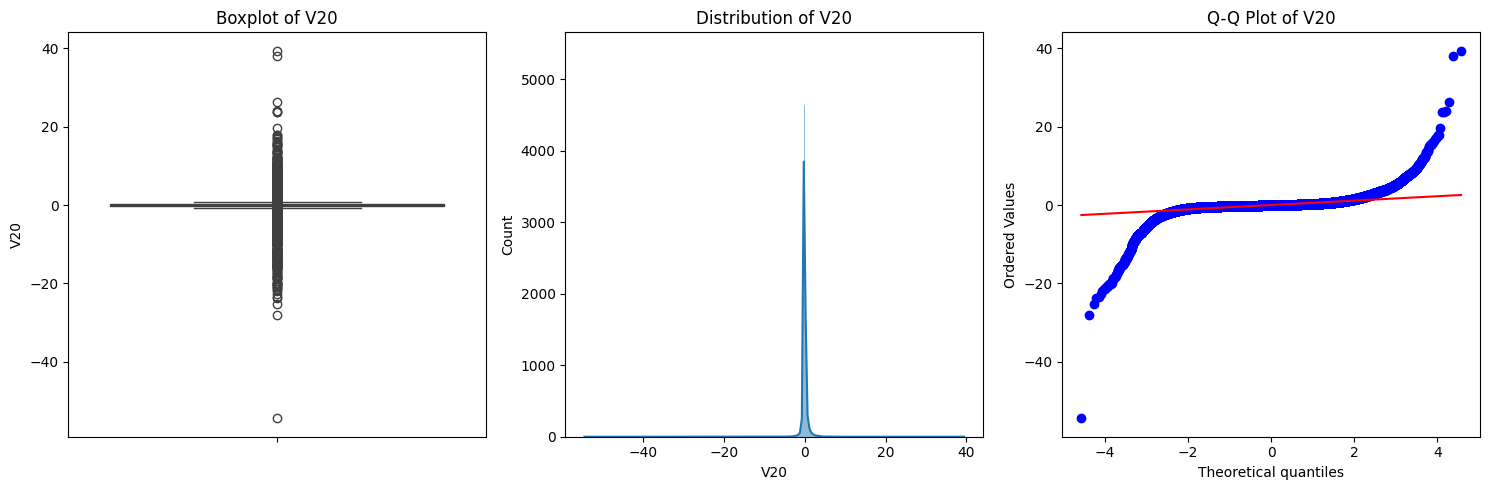

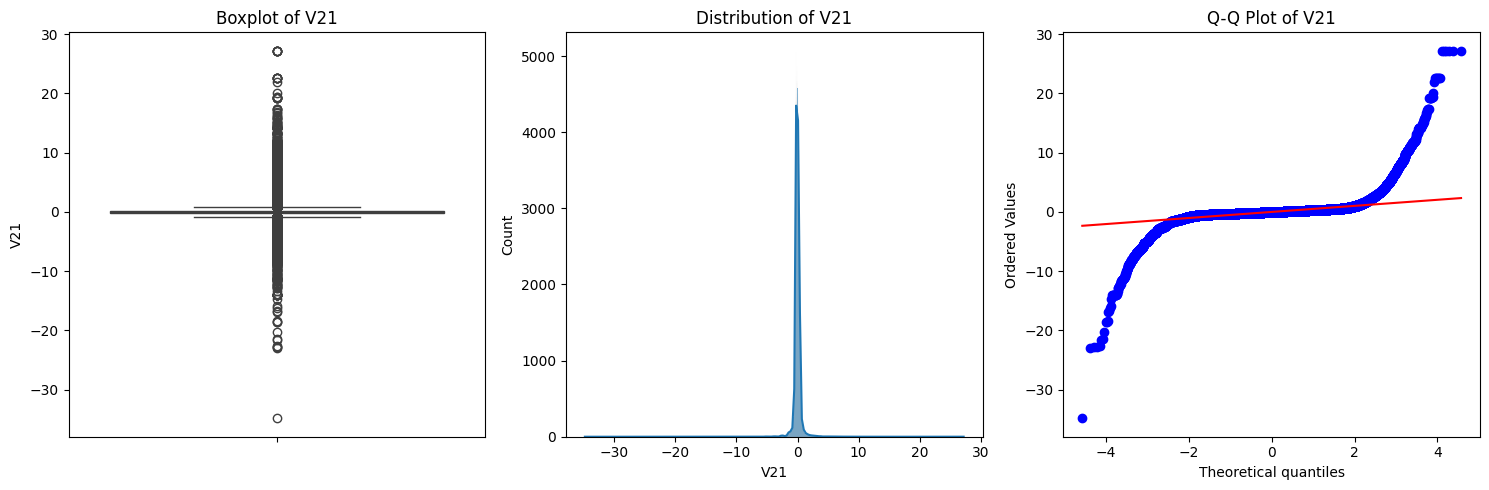

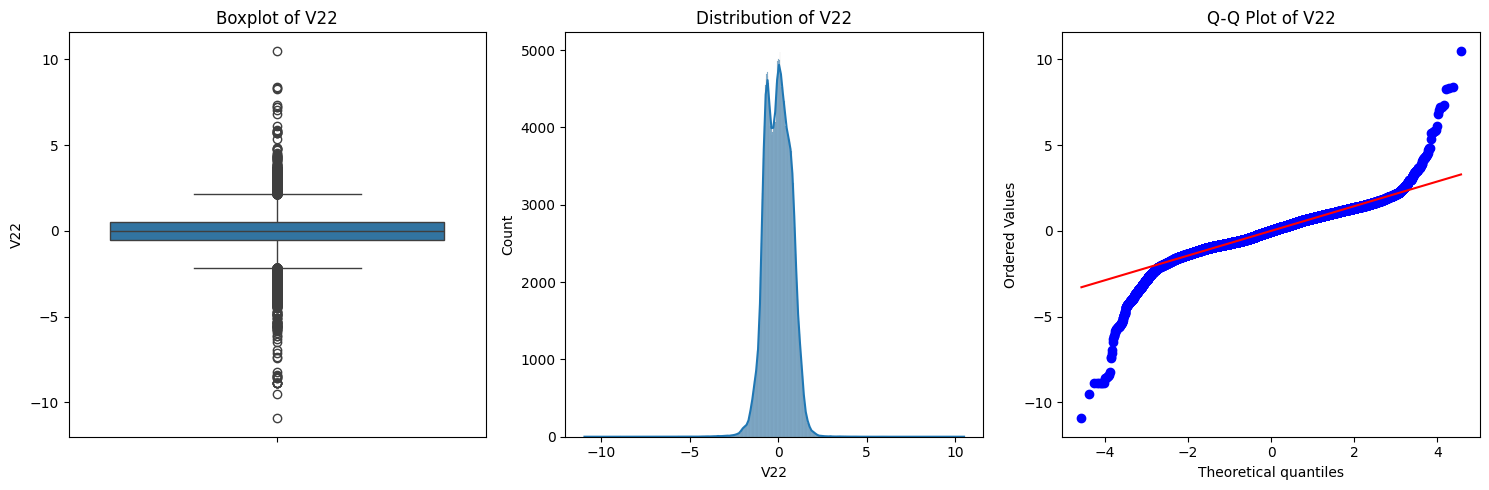

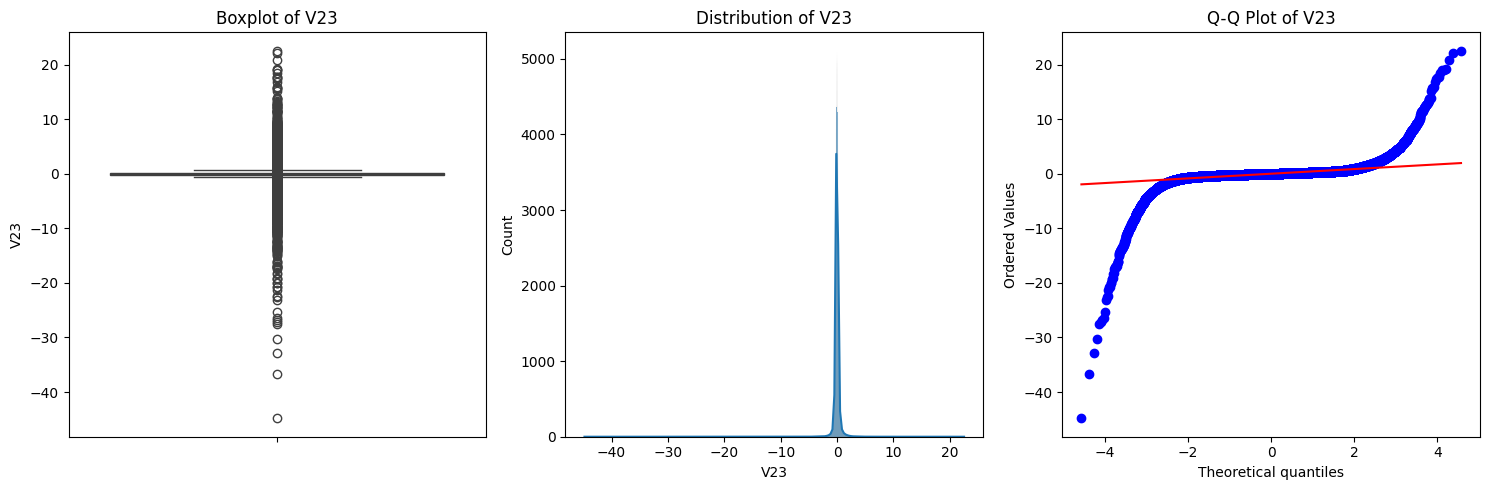

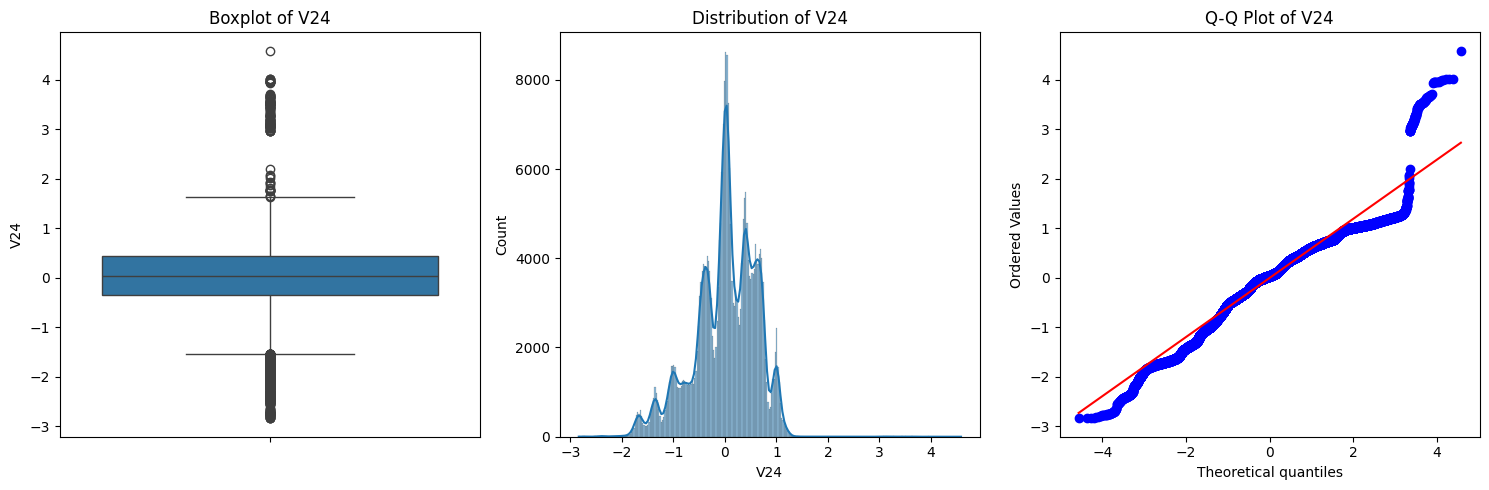

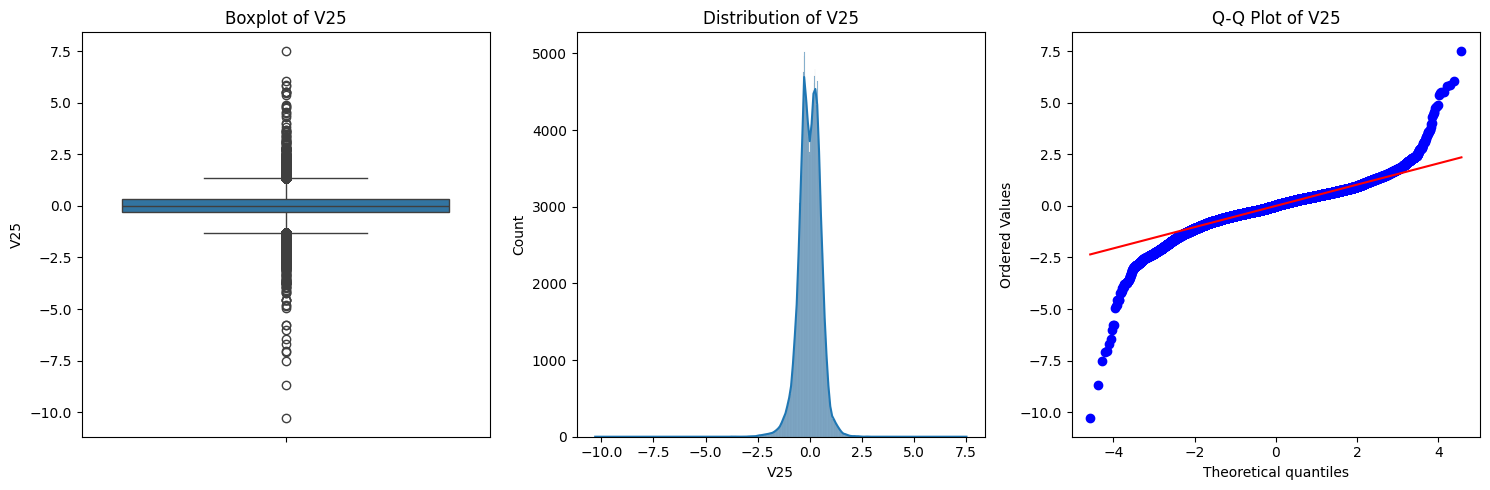

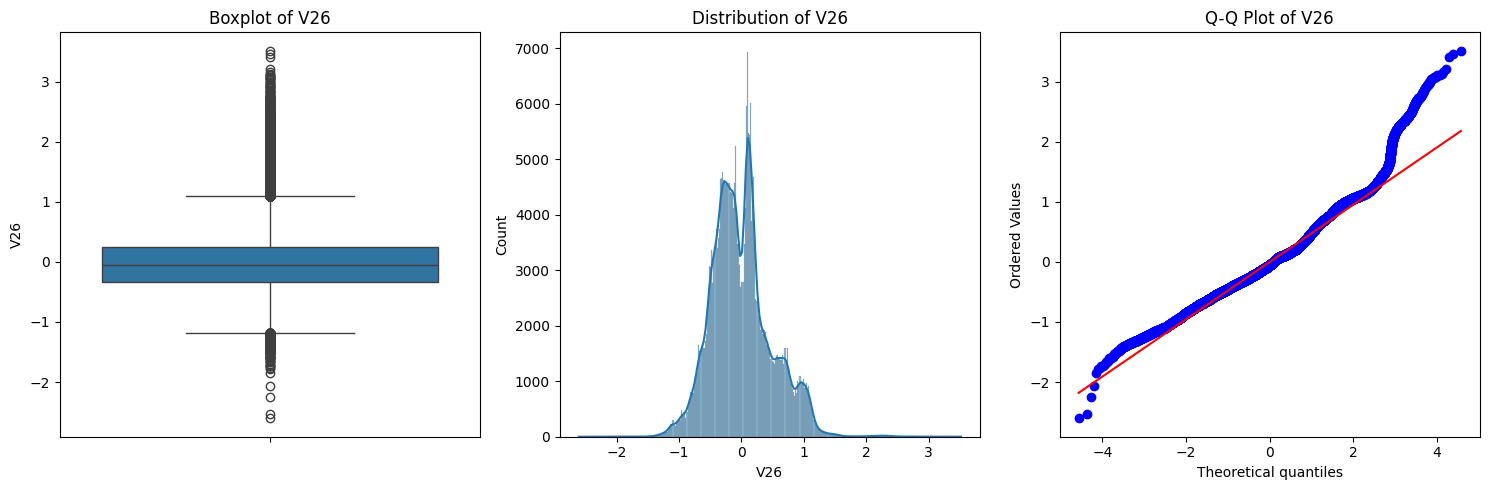

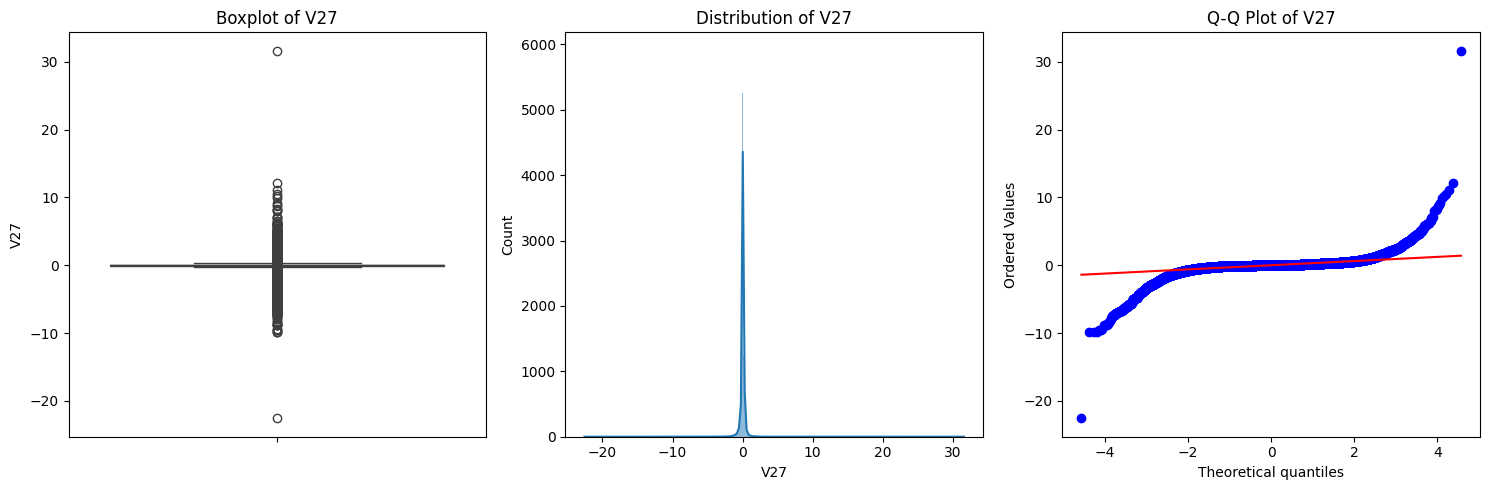

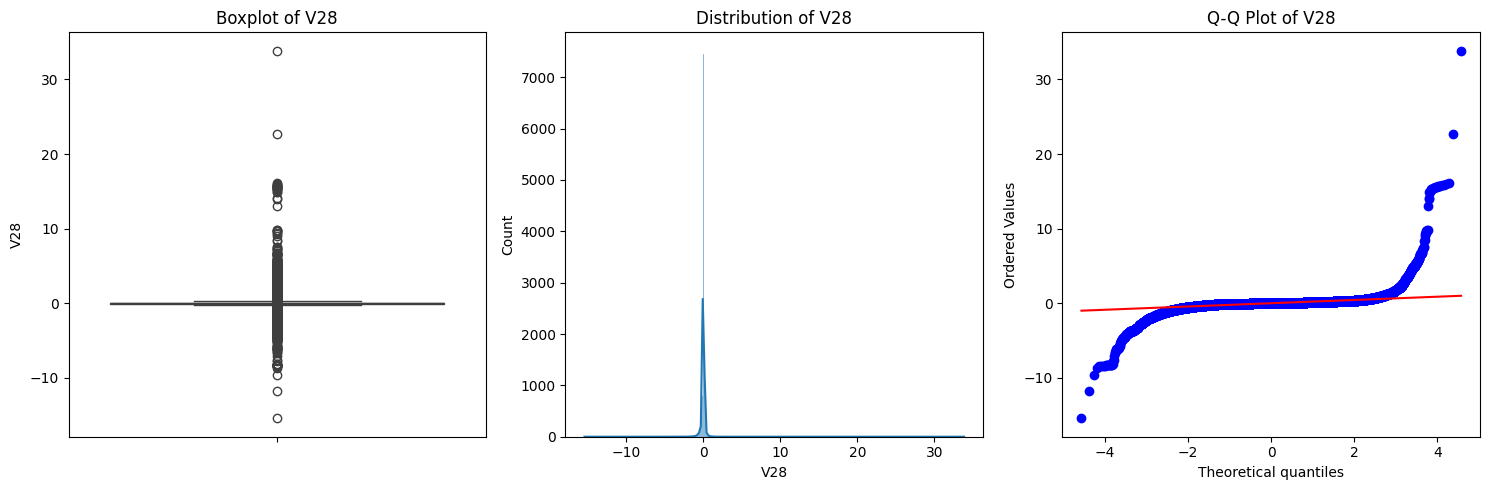

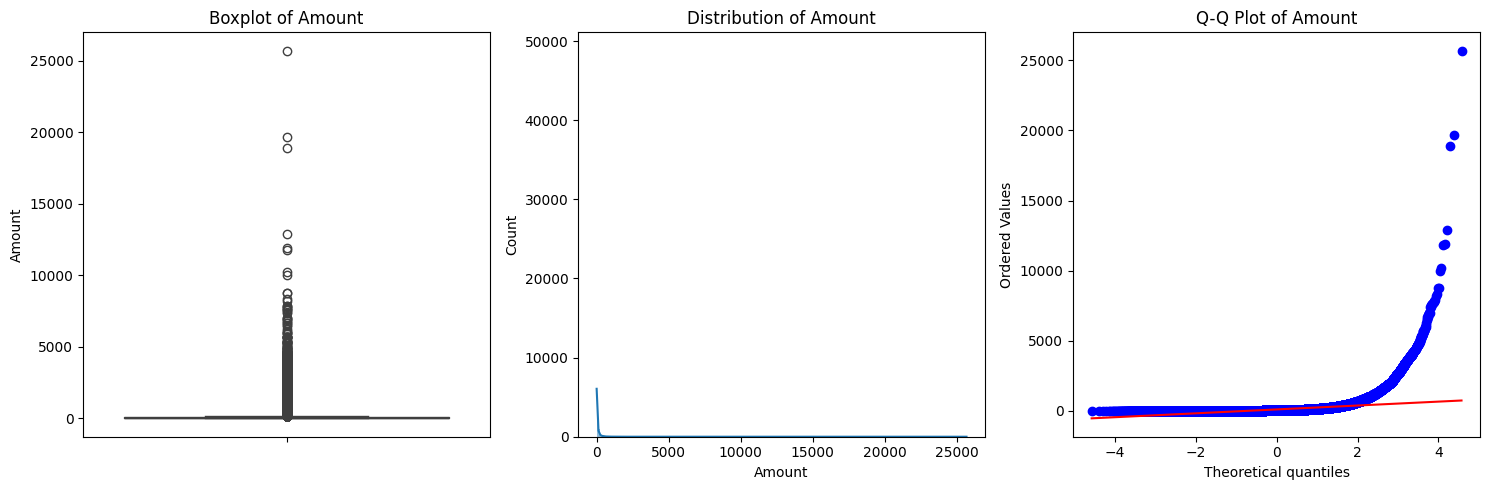

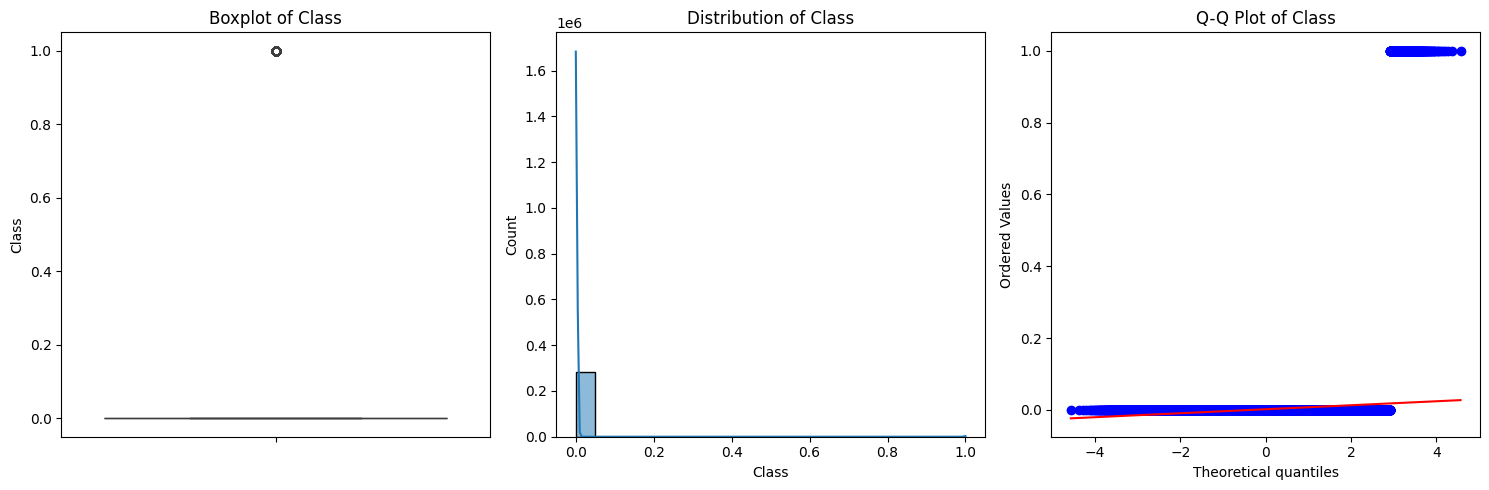

In [10]:
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
import seaborn as sns
from scipy import stats
# Create visualization for each feature
def plot_feature_distribution(data, feature):
    plt.figure(figsize=(15, 5))

    plt.subplot(131)
    sns.boxplot(data=data, y=feature)
    plt.title(f'Boxplot of {feature}')

    plt.subplot(132)
    sns.histplot(data=data, x=feature, kde=True)
    plt.title(f'Distribution of {feature}')

    plt.subplot(133)
    stats.probplot(data[feature], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {feature}')

    plt.tight_layout()
    plt.show()

# Plot distributions for each feature
for column in numeric_columns:
    plot_feature_distribution(data, column)

## Observation
The exploratory analysis of fetures reveals varying distributional characteristics. Some features are approximately symmetric around zero with minor departures from normality at the tails. some exhibits a highly peaked distribution with numerous extreme observations, indicating heavy-tailed behavior and substantial deviation from normality. V26 demonstrates moderate positive skewness with several upper-tail outliers. The Q-Q plots confirm that none of the  variables perfectly follow a Gaussian distribution. These findings suggest the presence of non-normal behavior and potential anomalies within the dataset, supporting the use of anomaly detection techniques  for fraud detection.

## Fraud Distribution

In [11]:
data["Class"].unique()

array([0, 1])

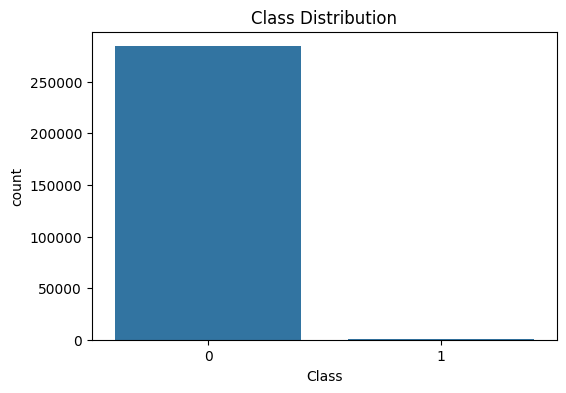

In [12]:
import seaborn as sns
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=data)

plt.title('Class Distribution')
plt.show()

In [13]:
print(data['Class'].value_counts())

print(data['Class'].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Observation
- Non-Fraud = 284315
- Fraud     = 492
- Fraud % = 0.172%

### Conclusion:

- Dataset is extremely imbalanced.
- Fraud transactions are very rare.
- This makes anomaly detection suitable.

## Amount Distribution

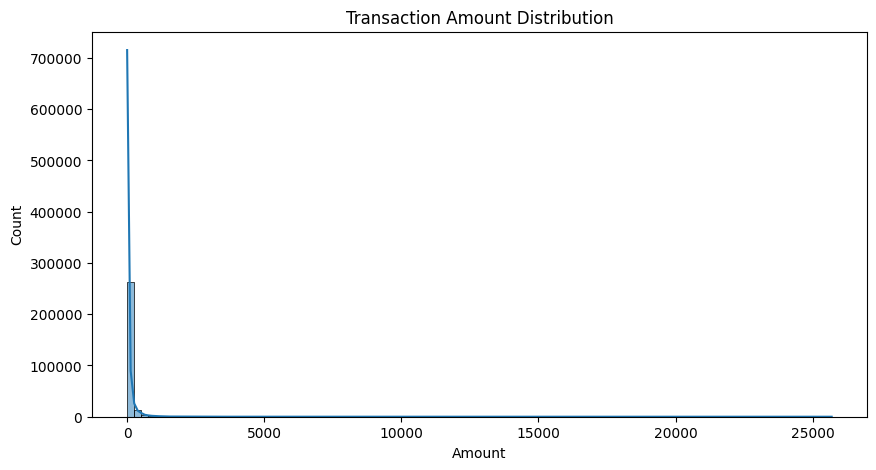

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(data['Amount'],
             bins=100,
             kde=True)

plt.title('Transaction Amount Distribution')
plt.show()

## Observation
 -Highly right-skewed.
- Majority of transactions are low-value.
- Few very large transactions.

## Log-Transformed Amount

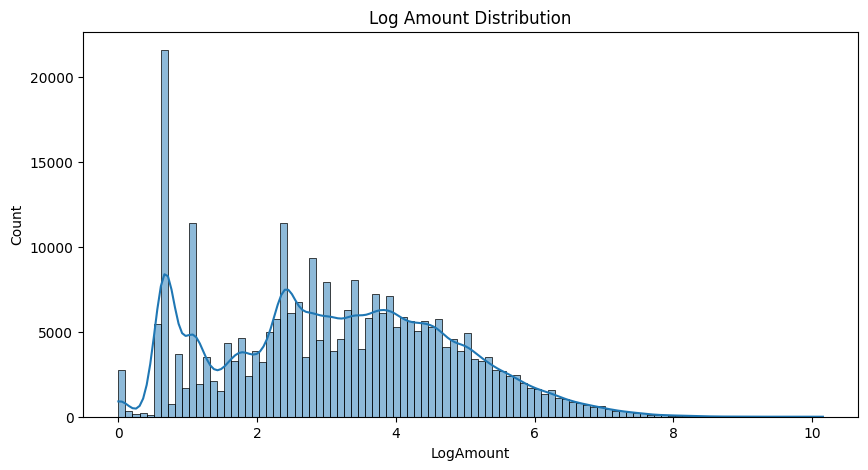

In [15]:
data['LogAmount'] = np.log1p(data['Amount'])

plt.figure(figsize=(10,5))

sns.histplot(data['LogAmount'],
             bins=100,
             kde=True)

plt.title('Log Amount Distribution')
plt.show()

## Observation
- Log transformation reduces skewness.
- Distribution becomes more interpretable.

## Fraud vs Amount

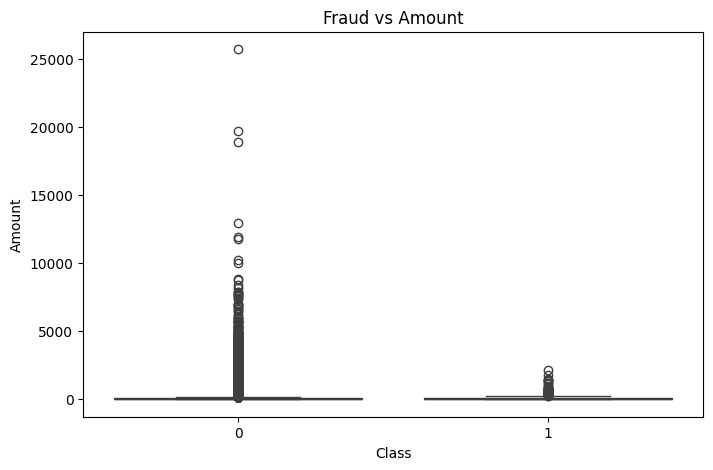

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class',
            y='Amount',
            data=data)

plt.title('Fraud vs Amount')
plt.show()

## Observation
- Fraudulent transactions occur across many amounts.
- Amount alone is not sufficient to identify fraud.

## Time Distribution

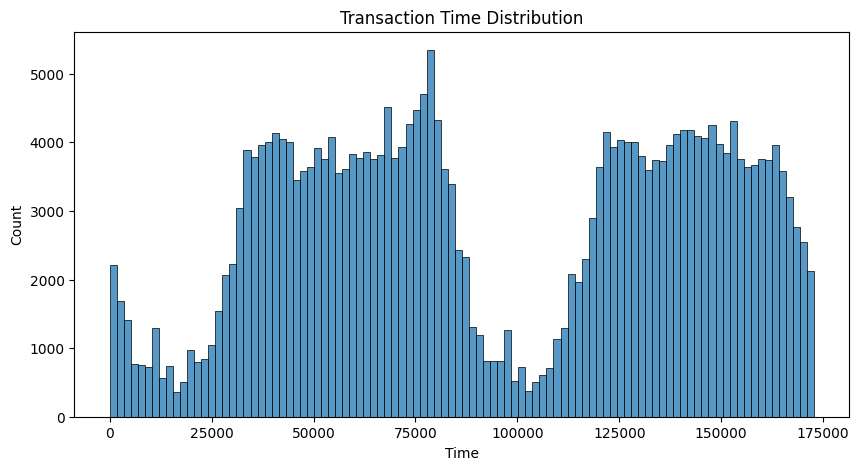

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(data['Time'],
             bins=100)

plt.title('Transaction Time Distribution')
plt.show()

### Observation
- Transactions occur throughout the observed period.
- Peaks correspond to higher activity periods.

## Correlation Heatmap

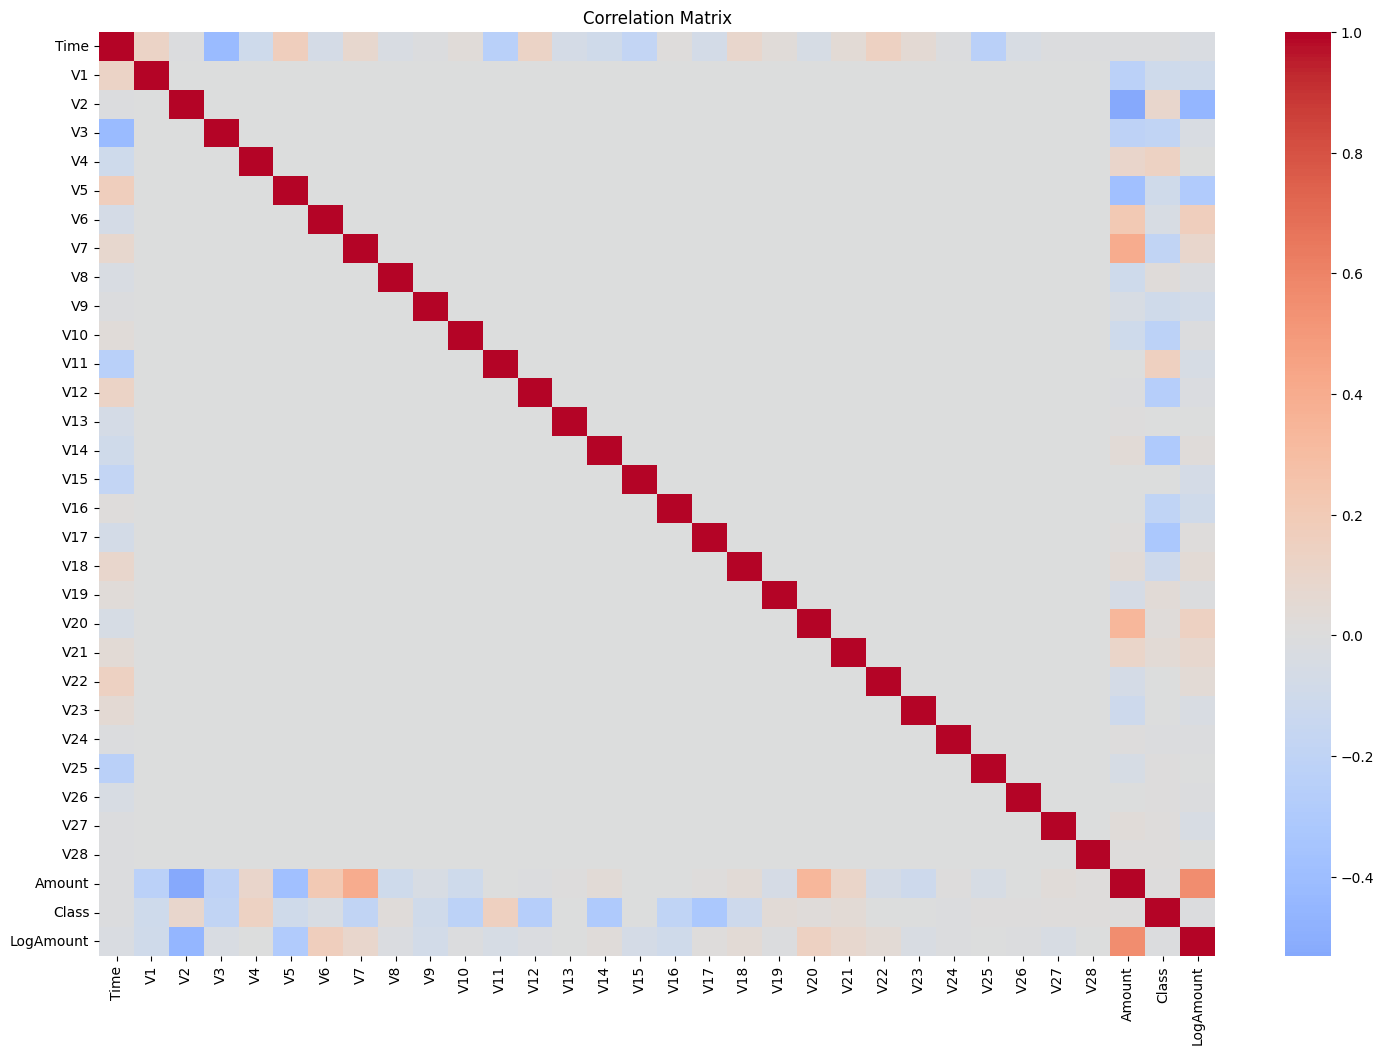

In [18]:
plt.figure(figsize=(18,12))

corr = data.corr()

sns.heatmap(corr,
            cmap='coolwarm',
            center=0)

plt.title('Correlation Matrix')
plt.show()

## Observation

- Important fraud-related features are:V10
| Feature | Correlation with Class |
| ------- | ---------------------- |
| V14     | Strong negative        |
| V17     | Strong negative        |
| V12     | Strong negative        |
| V10     | Strong negative        |
| V16     | Strong negative        |
| V11     | Positive               |
| V4      | Positive               |
| V18     | Negative               |

- They show stronger correlation with Class.

## Fraud Feature Analysis

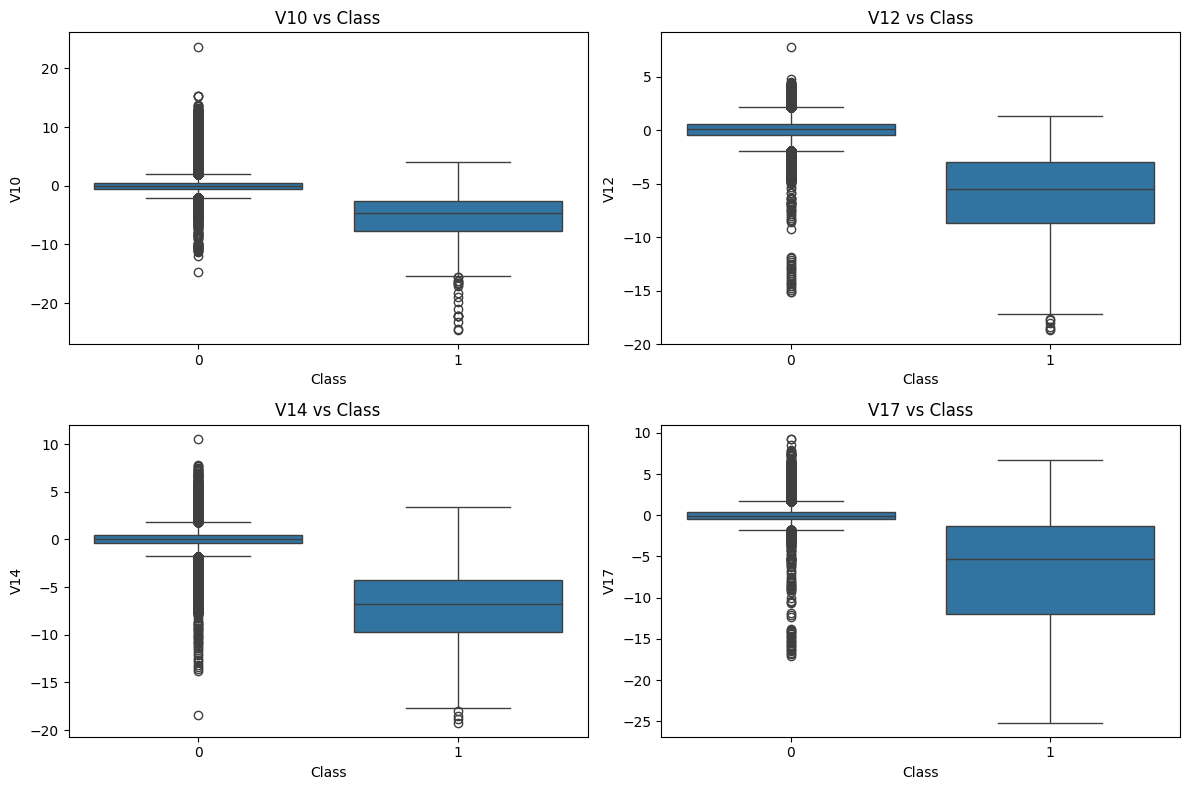

In [19]:
important = ['V10','V12','V14','V17']

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col in enumerate(important):

    sns.boxplot(
        x='Class',
        y=col,
        data=data,
        ax=axes[i//2, i%2]
    )

    axes[i//2, i%2].set_title(f'{col} vs Class')

plt.tight_layout()
plt.show()

## Observation
### The boxplots reveal clear differences between fraudulent and non-fraudulent transactions. Features V10, V12, V14, and V17 show substantial shifts in their distributions across the two classes. Fraudulent transactions generally exhibit lower median values and a wider spread than normal transactions. These features therefore appear to be highly informative for distinguishing fraudulent transactions and are likely important predictors in fraud detection models

## Anomaly Detection

- Since frauds are anomalies, I will use unsupervised methods.

### Isolation Forest

In [20]:
X = data.drop('Class', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
        contamination=0.00172,
        random_state=42)

pred = iso.fit_predict(X_scaled)

pred = np.where(pred==-1,1,0)

In [21]:
from sklearn.metrics import classification_report

print(classification_report(data['Class'], pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.26      0.26      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807



## Estimated Frauds Detected

- Since recall = 0.26:

- 0.26×492≈128

- So the model detected roughly 128 fraud transactions and missed roughly 364 fraud transactions.

### Observation
The Isolation Forest model achieved nearly perfect performance for normal transactions due to the overwhelming majority of non-fraudulent records in the dataset. However, fraud detection performance was modest, with precision, recall, and F1-score of approximately 0.26. This indicates that the model correctly identified only about 26% of fraudulent transactions while generating a substantial number of false positives. Although overall accuracy was close to 100%, accuracy is not an appropriate evaluation metric for this highly imbalanced dataset. Precision, recall, and F1-score provide a more realistic assessment of anomaly detection performance. The results demonstrate that while Isolation Forest can identify some fraudulent transactions, additional tuning or alternative anomaly detection techniques may be required to improve fraud detection effectiveness.

### Local Outlier Factor

In [22]:
lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.00172)

pred_lof = lof.fit_predict(X_scaled)

pred_lof = np.where(pred_lof==-1,1,0)

print(classification_report(data['Class'],
                            pred_lof))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



## Similarity-Based Transaction Search

### This is the Cosine Similarity = similarity(i,j) = dot product (vi, vj) / length(vi) * length(vj)

### Preparing Features

In [23]:
features = data.drop('Class', axis=1)

scaler = StandardScaler()

X = scaler.fit_transform(features)

### Take Sample of 100 Transactions

In [24]:
sample_idx = np.random.choice(
                len(X),
                size=100,
                replace=False)

sample = X[sample_idx]

### Compute Similarities

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
                        sample,
                        X)

In [26]:
(100, 284807)

(100, 284807)

**Find Top-10 Most Similar Transactions**

In [27]:
top10_dict = {}

for i in range(similarity_matrix.shape[0]):

    sims = similarity_matrix[i]

    top10 = np.argsort(sims)[::-1][1:11]

    top10_dict[i] = top10

**Dispaly Results**

In [28]:
for i in range(5):

    print(f"\nSample Transaction {i}")

    print("Top 10 Similar Transactions:")

    print(top10_dict[i])


Sample Transaction 0
Top 10 Similar Transactions:
[175439 187713 247528 162774 226368 179027 169327 224588 221671 209156]

Sample Transaction 1
Top 10 Similar Transactions:
[28399 28479 66733  3547 67075 62953 87239 87320 66263 58572]

Sample Transaction 2
Top 10 Similar Transactions:
[204919 252487 172049 231616 241703 246312 239855 174608 266908 234044]

Sample Transaction 3
Top 10 Similar Transactions:
[ 53622  16977 111247  16526  36432  22253  51122 134420  20822  48046]

Sample Transaction 4
Top 10 Similar Transactions:
[ 23195  64250  31838  43069  27714  71875 123651  84376  14529  21892]


**Similarity Heatmap for 100 Transactions**

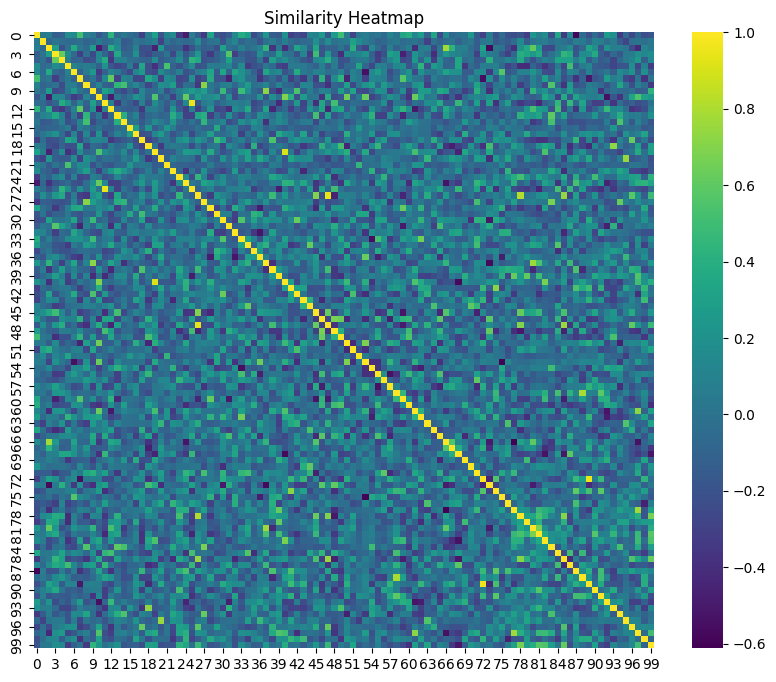

In [29]:
sample_similarity = cosine_similarity(sample)

plt.figure(figsize=(10,8))

sns.heatmap(sample_similarity,
            cmap='viridis')

plt.title('Similarity Heatmap')
plt.show()

# Observation
**Bright regions indicate highly similar transactions.
Dense blocks may represent transaction clusters.
Isolated rows may indicate anomalies/fraudulent behavior. **

# Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

## Step 1: Import the Required Libraries

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Step 2: Load the Dataset

In [2]:
df_db = pd.read_csv('CC GENERAL.csv')
df_db.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Step 3: Preprocess the Data

In [3]:
df_db = df_db.drop('CUST_ID', axis=1, errors='ignore')
df_db.fillna(df_db.mean(numeric_only=True), inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_db)
print(X_scaled.shape)

(8950, 17)


## Step 4: Reduce Dimensionality using PCA

Explained Variance Ratio: [0.27290037 0.20301991]


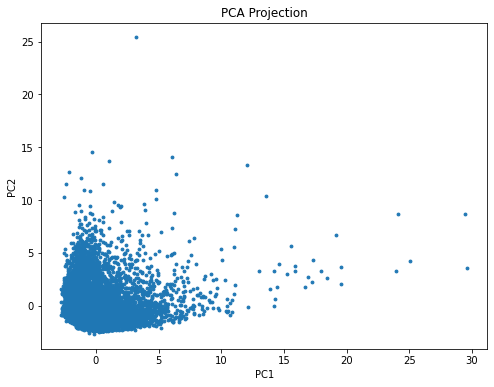

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Explained Variance Ratio:', pca.explained_variance_ratio_)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=8)
plt.title('PCA Projection')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

## Step 5: Build the DBSCAN Model

In [5]:
dbscan = DBSCAN(eps=0.8, min_samples=10)
labels = dbscan.fit_predict(X_pca)

df_db['Cluster']=labels

print('Number of clusters:', len(set(labels))-(1 if -1 in labels else 0))
print('Noise points:', np.sum(labels==-1))

Number of clusters: 2
Noise points: 106


## Step 6: Visualize the Clusters

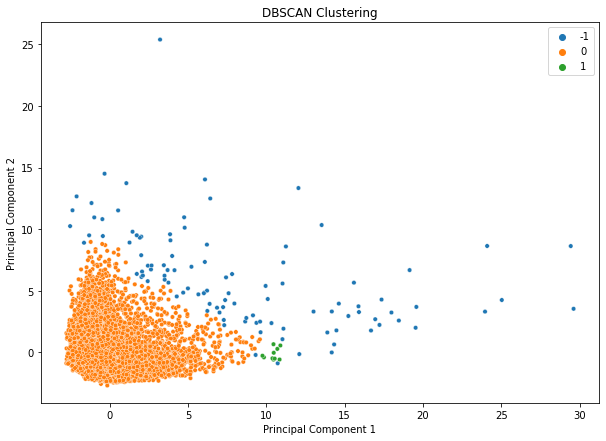

In [6]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=labels,palette='tab10',s=20,legend='full')
plt.title('DBSCAN Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Step 7: Tune DBSCAN Parameters

In [7]:
eps_values=[0.3,0.5,0.8,1.0]
for eps in eps_values:
    model=DBSCAN(eps=eps,min_samples=10)
    lab=model.fit_predict(X_pca)
    n_clusters=len(set(lab))-(1 if -1 in lab else 0)
    noise=np.sum(lab==-1)
    print(f'eps={eps}: clusters={n_clusters}, noise={noise}')

eps=0.3: clusters=5, noise=485
eps=0.5: clusters=4, noise=239
eps=0.8: clusters=2, noise=106
eps=1.0: clusters=1, noise=81


## 8: Visualizing the changes

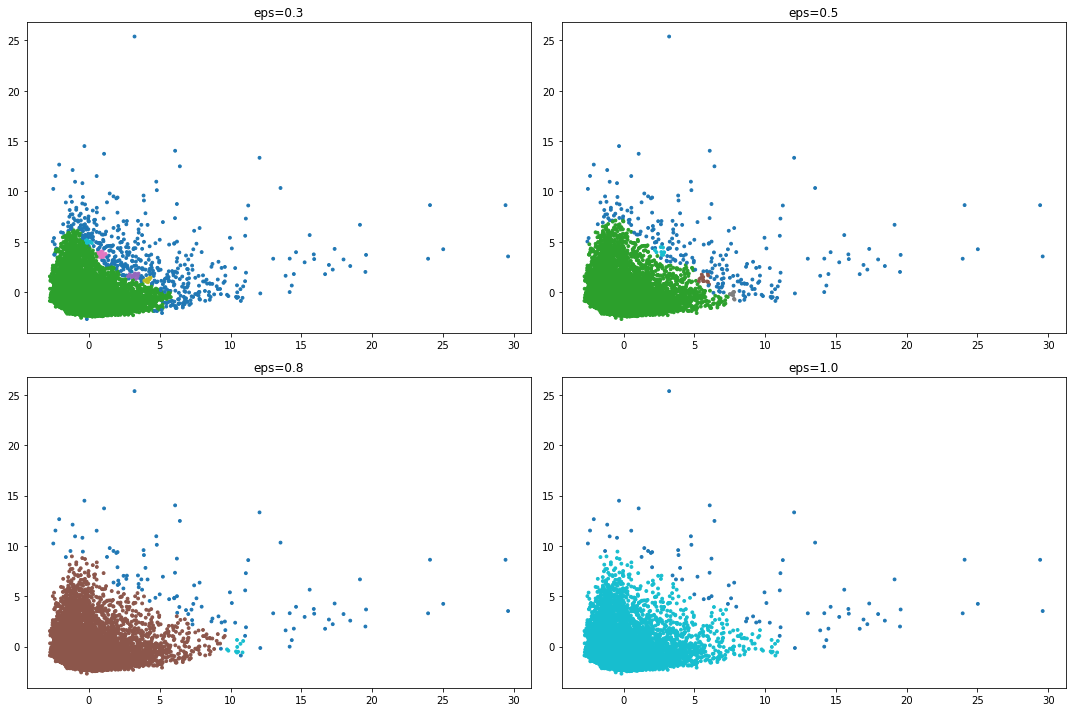

In [8]:
plt.figure(figsize=(15,10))
for i,eps in enumerate([0.3,0.5,0.8,1.0],1):
    plt.subplot(2,2,i)
    model=DBSCAN(eps=eps,min_samples=10)
    lab=model.fit_predict(X_pca)
    plt.scatter(X_pca[:,0],X_pca[:,1],c=lab,cmap='tab10',s=8)
    plt.title(f'eps={eps}')
plt.tight_layout()
plt.show()